# Proyecto 2 - Customer Analytics

### Contexto

Empresa llamada NovaShop que se dedica a la venta de productos de distintos tipos como electronica y muebleria por lo general, quiere un analisis de los miles de clientes que tienen

### Objetivo

Sabes quienes son los mejores clientes, que clientes estan dejando de comprar y donde deberian concentrar sus esfuerzos comerciales

### Preguntas del negocio
1. ¿Cual es el dinero total recaudado por cada segemento de clientes y que porcentaje total representa de los ingresos cada segemento?
2. ¿Que productos son los mas vendidos, cuales los menos, y como ha sido su comportamiento a traves del tiempo?
3. ¿Que productos son los mas comprados segun cada categoria de clientes?
4. ¿Cómo ha evolucionado el valor y la actividad de cada segmento a través del tiempo?, es decir, como se ha comportado cada segemento de clientes, si durante el tiempo han subido o bajado ingresos cada sector y especificamente que fechas se dejo de consumir mas?
5. ¿Qué clientes tienen mayor valor para la empresa y cuáles muestran señales de estar perdiendo actividad?

In [216]:
import pandas as pd
import matplotlib.pyplot as plt


# Cargar dataframes y csv

In [3]:
df_transc = pd.read_csv("C:/Users/luisr/OneDrive/Documentos/Ciencia de datos/NovaShop_transactions.csv")
df_customers = pd.read_csv("C:/Users/luisr/OneDrive/Documentos/Ciencia de datos/NovaShop_customers.csv")

# Analisis para Customers

In [55]:
df_customers.head()

,customer_id,city,segment
0,C0001,Puebla,Nuevo
1,C0002,Guadalajara,Ocasional
2,C0003,Querétaro,Frecuente
3,C0004,Puebla,Ocasional
4,C0005,CDMX,Ocasional


In [9]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  320 non-null    object
 1   city         316 non-null    object
 2   segment      320 non-null    object
dtypes: object(3)
memory usage: 7.6+ KB


In [23]:
df_customers[df_customers["customer_id"].duplicated()]

,customer_id,city,segment


In [19]:
df_customers[df_customers["city"].isna()]

,customer_id,city,segment
85,C0086,NaN,Nuevo
140,C0141,NaN,Ocasional
145,C0146,NaN,Ocasional
164,C0165,NaN,Premium


In [43]:
df_customers["city"].unique()

array(['Puebla', 'Guadalajara', 'Querétaro', 'CDMX', 'Mérida',
       'Monterrey', nan, 'guadalajara', 'cdmx', 'monterrey'], dtype=object)

In [45]:
df_customers["segment"].unique()

array(['Nuevo', 'Ocasional', 'Frecuente', 'Premium'], dtype=object)

### Analisis de Clientes
- 320 filas 
- 3 columnas que indican 
  - ID: Identificador
  - Ciudad: Sin información para confirmar si es ciudad de donde se compra o ciudad del cliente
  - Segemento: Categoria del cliente que pertenece
- 4 valores faltantes en city
- Las ciudades de Monterrey, CDMX y Guadalajara existen dos veces
- 4 segementos de clientes

In [113]:
df_customers["city"].replace("monterrey","Monterrey", inplace=True)
df_customers["city"].replace("cdmx","CDMX", inplace=True)
df_customers["city"].replace("guadalajara","Guadalajara", inplace=True)

In [114]:
df_customers["city"].unique()

array(['Puebla', 'Guadalajara', 'Querétaro', 'CDMX', 'Mérida',
       'Monterrey', nan], dtype=object)

# Analisis de Transacciones

In [115]:
df_transc.head()

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost
0,1,C0237,2026-02-08,Escritorio,Muebles,1,6500,0.00,4300
1,2,C0033,2025-12-06,Escritorio,Muebles,1,6500,0.05,4300
2,3,C0085,2026-01-05,Laptop Pro,Tecnología,2,18500,0.00,12500
3,4,C0133,2026-04-11,Teclado Mecánico,Accesorios,2,1800,0.00,1050
4,5,C0037,2025-05-31,Mochila,Accesorios,1,1400,0.00,700


In [116]:
df_transc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     2400 non-null   int64         
 1   customer_id  2400 non-null   object        
 2   date         2395 non-null   datetime64[ns]
 3   product      2400 non-null   object        
 4   category     2400 non-null   object        
 5   quantity     2400 non-null   int64         
 6   unit_price   2400 non-null   int64         
 7   discount     2400 non-null   float64       
 8   unit_cost    2400 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 187.5+ KB


In [26]:
df_transc.isna().sum()

order_id        0
customer_id     0
date            5
product         0
category       10
quantity        0
unit_price      0
discount        4
unit_cost       0
dtype: int64

In [52]:
df_transc[df_transc["order_id"].duplicated()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost
2400,1414,C0253,2025-02-09,Teclado Mecánico,Accesorios,1,1800,0.00,1050
2401,639,C0141,2025-11-02,Monitor 24,Tecnología,1,5200,0.10,3400
2402,1184,C0183,2025-02-01,Tablet,Tecnología,1,8200,0.05,5400
2403,1666,C0049,2025-08-28,Laptop Pro,Tecnología,1,18500,0.05,12500
2404,2069,C0158,2026-02-22,Teclado Mecánico,Accesorios,3,1800,0.05,1050
2405,790,C0152,2025-08-30,Monitor 24,Tecnología,2,5200,0.05,3400
2406,1990,C0039,2026-05-06,Monitor 24,Tecnología,1,5200,0.05,3400
2407,1583,C0090,2025-04-04,Silla Ergonómica,Muebles,1,4800,0.00,3000
2408,1030,C0052,2025-08-31,Tablet,Tecnología,1,8200,0.00,5400
2409,1435,C0008,2025-03-29,Tablet,Tecnología,2,8200,0.05,5400


In [57]:
# Compras con cantidades en 0
df_transc[(df_transc["quantity"] == 0) 
          | (df_transc["unit_price"] == 0)
          | (df_transc["unit_cost"] == 0)]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost
821,822,C0176,2025-05-30,Mouse Inalámbrico,Accesorios,0,900,0.00,500
1124,1125,C0202,2026-01-01,Mouse Inalámbrico,Accesorios,0,900,0.05,500
1498,1499,C0029,2026-01-26,Laptop Pro,Tecnología,0,18500,0.00,12500
1686,1687,C0225,2025-06-12,Monitor 24,Tecnología,0,5200,0.00,3400
1907,1908,C0196,2026-01-31,Mouse Inalámbrico,Accesorios,0,900,0.10,500
2384,2385,C0033,2025-10-13,Webcam,Accesorios,0,1600,0.10,900


In [62]:
df_transc["category"].unique()

array(['Muebles', 'Tecnología', 'Accesorios', nan], dtype=object)

Los rangos de fecha de este data set estan entre 2025-01-01 / 2026-06-30

In [63]:
df_transc["product"].unique()

array(['Escritorio', 'Laptop Pro', 'Teclado Mecánico', 'Mochila',
       'Silla Ergonómica', 'Audífonos', 'Tablet', 'Monitor 24',
       'Mouse Inalámbrico', 'Webcam'], dtype=object)

### Analisis de transacciones

- La fecha data desde 2025-01-01 / 2026-06-30
- Existen 9 columnas donde cada una representa lo siguiente:
  - order_id: Identificador de orden
  - customer_id: Identificador del cliente
  - date: Dia de compra
  -	product: Producto comprado
  -	category: Categoria del producto comprado 
  -	quantity: Cantidad comprada
  -	unit_price: Precio del producto
  -	discount: Descuento aplicado
  -	unit_cost: Precio de compra del producto
- Existen un total de 19 valores faltantes en date, category y discount
- Existen 9 registros duplicados en el identificador de compras
- Existen 6 registros con cantidad 0 de productos comprados
- El tipo de dato de date es objeto no fecha

# Limpieza de datos
### Ordenes duplicadas

Borraremos las ordenes duplicadas

In [72]:
df_transc.drop_duplicates(inplace=True)

Corroboramos que no haya datos duplicados

In [73]:
df_transc[df_transc["order_id"].duplicated()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost


# Valores faltantes en category

In [77]:
df_transc[df_transc["category"].isna()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost
133,134,C0234,2026-04-23,Laptop Pro,NaN,1,18500,0.05,12500
542,543,C0045,2026-03-24,Monitor 24,NaN,1,5200,0.10,3400
724,725,C0166,2026-01-31,Laptop Pro,NaN,2,18500,0.00,12500
1391,1392,C0298,2026-01-23,Tablet,NaN,2,8200,0.05,5400
1502,1503,C0308,2026-02-21,Tablet,NaN,1,8200,0.10,5400
1645,1646,C0150,2025-04-07,Mochila,NaN,2,1400,0.00,700
1867,1868,C0262,2025-04-07,Audífonos,NaN,1,2100,0.10,1250
2008,2009,C0223,2026-03-12,Escritorio,NaN,2,6500,0.05,4300
2158,2159,C0017,2025-03-20,Mochila,NaN,1,1400,0.00,700
2270,2271,C0194,2026-05-17,Escritorio,NaN,1,6500,0.15,4300


In [88]:
mapeo = df_transc.set_index("product")["category"].to_dict()
mapeo

{'Escritorio': 'Muebles',
 'Laptop Pro': 'Tecnología',
 'Teclado Mecánico': 'Accesorios',
 'Mochila': 'Accesorios',
 'Silla Ergonómica': 'Muebles',
 'Audífonos': 'Accesorios',
 'Tablet': 'Tecnología',
 'Monitor 24': 'Tecnología',
 'Mouse Inalámbrico': 'Accesorios',
 'Webcam': 'Accesorios'}

In [89]:
df_transc["category"]= df_transc["category"].fillna(df_transc["product"].map(mapeo))

In [90]:
df_transc[df_transc["category"].isna()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost


# Valores faltantes en discount

In [92]:
df_transc[df_transc["discount"].isna()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost
1151,1152,C0305,2025-03-28,Teclado Mecánico,Accesorios,2,1800,NaN,1050
1215,1216,C0318,2025-11-17,Teclado Mecánico,Accesorios,3,1800,NaN,1050
1335,1336,C0139,2025-05-19,Webcam,Accesorios,1,1600,NaN,900
1404,1405,C0301,2025-04-21,Laptop Pro,Tecnología,2,18500,NaN,12500


Dos caminos, si podemos conocer que la empresa tiene cierta 
cantidad de descuento cada cierta cantidad de productos podemos tomar esa estretegia, en este caso al no saber tomaremos un promedio del descuento que se hacen para esos productos

In [106]:
promedio_teclado = df_transc.loc[df_transc["product"]=="Teclado Mecánico","discount"].mean()
print("Promedio del teclado: ", promedio_teclado)
promedio_webcam = df_transc.loc[df_transc["product"]=="Webcam","discount"].mean()
print("Promedio del webcam: ", promedio_webcam)
promedio_Laptop = df_transc.loc[df_transc["product"]=="Laptop Pro","discount"].mean()
print("Promedio del Laptop Pro: ", promedio_Laptop)


# rendondeamos los promedios
descuento_prom = {
    "Teclado Mecánico": 0.05,
    "Webcam": 0.05,
    "Laptop Pro": 0.05
}

df_transc["discount"] = df_transc["discount"].fillna(df_transc["product"].map(descuento_prom))


Promedio del teclado:  0.05305343511450382
Promedio del webcam:  0.04570552147239264
Promedio del Laptop Pro:  0.04757785467128028


In [107]:
df_transc[df_transc["discount"].isna()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost


## Valores faltantes en date

In [74]:
df_transc[df_transc["date"].isna()]

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost
671,672,C0313,NaN,Audífonos,Accesorios,1,2100,0.15,1250
730,731,C0311,NaN,Tablet,Tecnología,1,8200,0.20,5400
823,824,C0091,NaN,Audífonos,Accesorios,1,2100,0.05,1250
1126,1127,C0105,NaN,Escritorio,Muebles,1,6500,0.10,4300
1966,1967,C0279,NaN,Mouse Inalámbrico,Accesorios,1,900,0.10,500


Los valores de date los dejaremos como estan debido a que no existe referencias en el cual podamos concluir en que fechas se realizaron ciertas compras

# Valores faltantes en quantity

En quantity tampoco podemos determinar el numero exacto de compras que puede hacer los clientes, a diferencia de los descuentos donde se puede calcular el aproximado, aqui el rango puede variar mucho

# Cambiar valores date

In [108]:
df_transc["date"] = pd.to_datetime(df_transc["date"])

In [109]:
df_transc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     2400 non-null   int64         
 1   customer_id  2400 non-null   object        
 2   date         2395 non-null   datetime64[ns]
 3   product      2400 non-null   object        
 4   category     2400 non-null   object        
 5   quantity     2400 non-null   int64         
 6   unit_price   2400 non-null   int64         
 7   discount     2400 non-null   float64       
 8   unit_cost    2400 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 187.5+ KB


### Clientes que generan mayores ingresos

Primero necesitamos crear metricas, vamos a crear metricas importantes como:
- Revenue: Cuanto dinero ingresa
- Profit: Cuanta utilidad de dinero realmente ingreso

In [123]:
df_transc["Revenue"] = df_transc["quantity"] * df_transc["unit_price"] -(1*df_transc["discount"])
df_transc.head()

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost,Revenue
0,1,C0237,2026-02-08,Escritorio,Muebles,1,6500,0.00,4300,6500.00
1,2,C0033,2025-12-06,Escritorio,Muebles,1,6500,0.05,4300,6499.95
2,3,C0085,2026-01-05,Laptop Pro,Tecnología,2,18500,0.00,12500,37000.00
3,4,C0133,2026-04-11,Teclado Mecánico,Accesorios,2,1800,0.00,1050,3600.00
4,5,C0037,2025-05-31,Mochila,Accesorios,1,1400,0.00,700,1400.00


In [126]:
df_transc["profit"]= df_transc["Revenue"]-(df_transc["unit_cost"]*df_transc["quantity"])
df_transc.head()

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost,Revenue,profit
0,1,C0237,2026-02-08,Escritorio,Muebles,1,6500,0.00,4300,6500.00,2200.00
1,2,C0033,2025-12-06,Escritorio,Muebles,1,6500,0.05,4300,6499.95,2199.95
2,3,C0085,2026-01-05,Laptop Pro,Tecnología,2,18500,0.00,12500,37000.00,12000.00
3,4,C0133,2026-04-11,Teclado Mecánico,Accesorios,2,1800,0.00,1050,3600.00,1500.00
4,5,C0037,2025-05-31,Mochila,Accesorios,1,1400,0.00,700,1400.00,700.00


Ahora vamos analizar con estas metricas los clientes que genera mas ingresos

In [144]:
df_transc.groupby("customer_id")["Revenue"].sum().sort_values(ascending=False).head(10)

customer_id
C0237    241799.30
C0089    228399.45
C0171    224599.00
C0315    223499.45
C0043    223299.50
C0216    206299.60
C0228    197499.50
C0046    193298.95
C0071    186499.70
C0154    181099.60
Name: Revenue, dtype: float64

Ahora veamos los clientes que mayor profit generan

In [142]:
df_transc.groupby("customer_id")["profit"].sum().sort_values(ascending=False).head(10)

customer_id
C0237    82199.30
C0089    76599.45
C0171    76199.00
C0043    75299.50
C0315    74299.45
C0216    69399.60
C0228    65949.50
C0046    65398.95
C0071    63949.70
C0316    60999.30
Name: profit, dtype: float64

# Integración de la información
Necesitamos incorporar ciudad y segmento a las transacciones.

La llave común es `customer_id`.

Conceptualmente, esta operación equivale a un `LEFT JOIN` en SQL.

In [ ]:
df = df_transc.merge( df_customers, on="customer_id", how="left")
df.head()

,order_id,customer_id,date,product,category,quantity,unit_price,discount,unit_cost,Revenue,profit,city,segment
0,1,C0237,2026-02-08,Escritorio,Muebles,1,6500,0.00,4300,6500.00,2200.00,Monterrey,Frecuente
1,2,C0033,2025-12-06,Escritorio,Muebles,1,6500,0.05,4300,6499.95,2199.95,Guadalajara,Ocasional
2,3,C0085,2026-01-05,Laptop Pro,Tecnología,2,18500,0.00,12500,37000.00,12000.00,CDMX,Nuevo
3,4,C0133,2026-04-11,Teclado Mecánico,Accesorios,2,1800,0.00,1050,3600.00,1500.00,Monterrey,Ocasional
4,5,C0037,2025-05-31,Mochila,Accesorios,1,1400,0.00,700,1400.00,700.00,CDMX,Ocasional


# Customer Analytics

Ahora cambiamos de nivel: dejamos de estudiar solamente transacciones y construimos una tabla donde cada fila representa un cliente.

Utilizaremos RFM:

- **Recency:** días desde la última compra.
- **Frequency:** número de compras.
- **Monetary:** revenue generado.

In [210]:
df_rfm = df_customers["customer_id"]

In [211]:
rfm_df = df.groupby("customer_id",as_index=False)["date"].max()
rfm_df["recency"]=(df["date"].max()-rfm_df["date"]).dt.days
rfm_df["frequency"]= df.groupby("customer_id",as_index=False)["customer_id"].count()
rfm_df["monetary"]=df.groupby("customer_id")["Revenue"].sum().values
rfm_df.head()

,customer_id,date,recency,frequency,monetary
0,C0001,2026-06-26,4,8,17299.60
1,C0002,2025-10-01,272,4,17399.80
2,C0003,2025-05-10,416,1,18499.95
3,C0004,2026-06-12,18,11,88499.60
4,C0005,2026-04-06,85,6,47399.80


# Scores RFM

Convertimos cada dimensión en una puntuación de 1 a 5.

Para Recency:

- 5 = compró recientemente.
- 1 = lleva mucho tiempo sin comprar.

Para Frequency y Monetary:

- 5 = valores altos.
- 1 = valores bajos.

In [212]:
rfm_df["recency"] = pd.qcut(rfm_df["recency"],5, labels=[5, 4, 3, 2, 1])

rfm_df["frequency"] = pd.qcut(rfm_df["frequency"].rank(method="first"),5, labels=[1, 2, 3, 4, 5])

rfm_df["monetary"] = pd.qcut(rfm_df["monetary"],5,labels=[1, 2, 3, 4, 5])

rfm_df.head()

,customer_id,date,recency,frequency,monetary
0,C0001,2026-06-26,5,3,1
1,C0002,2025-10-01,1,1,1
2,C0003,2025-05-10,1,1,1
3,C0004,2026-06-12,4,5,4
4,C0005,2026-04-06,2,2,2


El RFM score suma las tres dimensiones.

El máximo posible es 15.

Se utilizan cuatro grupos interpretables para el negocio:

- En riesgo
- Ocasional
- Valioso
- VIP

In [214]:
rfm_df["RFM_score"] = (rfm_df["recency"].astype(int)+ rfm_df["frequency"].astype(int) + rfm_df["monetary"].astype(int))

rfm_df["RFM_segmento"] = pd.cut(rfm_df["RFM_score"],bins=[0, 5, 8, 11, 15],labels=["En riesgo", "Ocasional", "Valioso", "VIP"]
)
rfm_df.head()

,customer_id,date,recency,frequency,monetary,RFM_score,RFM_segmento
0,C0001,2026-06-26,5,3,1,9,Valioso
1,C0002,2025-10-01,1,1,1,3,En riesgo
2,C0003,2025-05-10,1,1,1,3,En riesgo
3,C0004,2026-06-12,4,5,4,13,VIP
4,C0005,2026-04-06,2,2,2,6,Ocasional


# Dsitribución de clientes

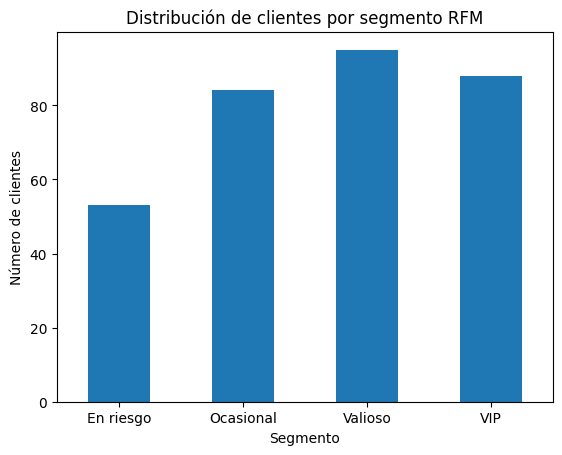

In [217]:
rfm_df["RFM_segmento"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de clientes por segmento RFM")
plt.xlabel("Segmento")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()

NovaShop presenta una distribución heterogénea de clientes. El análisis permite identificar diferencias entre los segmentos comerciales y construir una segmentación adicional basada en comportamiento mediante RFM.

Los clientes VIP y valiosos representan una oportunidad de retención, mientras que los clientes clasificados como en riesgo pueden ser candidatos para campañas de reactivación.

La segmentación RFM describe el comportamiento observado, pero no demuestra por sí sola las causas de abandono o cambio de comportamiento. Para profundizar sería útil incorporar variables como campañas recibidas, satisfacción, devoluciones, tiempos de entrega e interacción con la plataforma.